In [ ]:
import kagglehub
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bitcoin-historical-data' dataset.
Path to dataset files: /kaggle/input/bitcoin-historical-data


**IMPORTING THE FILES**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**READ THE CSV**

In [15]:
df = pd.read_csv('BTC-Hourly.csv')
print(df.shape)
df.head()

(33259, 9)


,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43312.27,52.056320,2.254677e+06
1,1646089200,2022-02-28 23:00:00,BTC/USD,43085.30,43364.81,42892.37,43178.98,106.816103,4.612210e+06
2,1646085600,2022-02-28 22:00:00,BTC/USD,41657.23,44256.08,41650.29,42907.32,527.540571,2.263535e+07
3,1646082000,2022-02-28 21:00:00,BTC/USD,41917.09,41917.09,41542.60,41659.53,69.751680,2.905822e+06
4,1646078400,2022-02-28 20:00:00,BTC/USD,41361.99,41971.00,41284.11,41914.97,247.151654,1.035935e+07


EDA

In [16]:
df.describe()

,unix,open,high,low,close,Volume BTC,Volume USD
count,3.325900e+04,33259.000000,33259.000000,33259.000000,33259.000000,3.325900e+04,3.325900e+04
mean,1.586228e+09,20119.546772,20232.957473,19997.069777,20120.684800,1.612380e+06,2.965701e+06
std,3.456429e+07,18537.219607,18646.950933,18418.320297,18537.695044,3.102328e+06,7.329787e+06
min,1.526364e+09,3139.760000,3158.340000,3122.280000,3139.760000,0.000000e+00,0.000000e+00
25%,1.556296e+09,7022.865000,7055.835000,6970.570000,7022.865000,1.903241e+02,1.682800e+02
50%,1.586228e+09,9700.040000,9740.270000,9657.000000,9700.320000,6.093271e+05,5.248300e+02
75%,1.616161e+09,36415.305000,36735.380000,36104.235000,36423.040000,1.929240e+06,3.120014e+06
max,1.646093e+09,68635.050000,69000.000000,68447.000000,68627.010000,6.857061e+07,2.582324e+08


In [17]:
df.isnull().sum()

,0
unix,0
date,0
symbol,0
open,0
high,0
low,0
close,0
Volume BTC,0
Volume USD,0


In [18]:
print(df.columns.tolist())

['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD']


In [19]:
df.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43312.27,52.056320,2.254677e+06
1,1646089200,2022-02-28 23:00:00,BTC/USD,43085.30,43364.81,42892.37,43178.98,106.816103,4.612210e+06
2,1646085600,2022-02-28 22:00:00,BTC/USD,41657.23,44256.08,41650.29,42907.32,527.540571,2.263535e+07
3,1646082000,2022-02-28 21:00:00,BTC/USD,41917.09,41917.09,41542.60,41659.53,69.751680,2.905822e+06
4,1646078400,2022-02-28 20:00:00,BTC/USD,41361.99,41971.00,41284.11,41914.97,247.151654,1.035935e+07


REVOME NULL VALUES

In [20]:
df.dropna(inplace=True)

In [21]:
df.isnull().sum()

,0
unix,0
date,0
symbol,0
open,0
high,0
low,0
close,0
Volume BTC,0
Volume USD,0


In [23]:
print(df['close'])
print(df.shape)

INITIALIZING FEARTURES

In [24]:
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
df.dropna(inplace=True)
df['target'].value_counts()

,count
target,
0,16934
1,16325


In [34]:
df['avg_50'] = df['close'].rolling(50).mean()

df['momentum'] = df['close'] - df['close'].shift(5)

df['avg_10'] = df['close'].rolling(10).mean()

df['avg_30'] = df['close'].rolling(30).mean()

df['MA_diff'] = df['avg_10'] - df['avg_30']

df['price_change'] = df['close'].pct_change()

df['volatility'] = df['close'].rolling(10).std()


df['avg_20'] = df['close'].rolling(20).mean()


delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/loss))


df['BB_upper'] = df['avg_20'] + 2 * df['close'].rolling(20).std()
df['BB_lower'] = df['avg_20'] - 2 * df['close'].rolling(20).std()
df['BB_width'] = df['BB_upper'] - df['BB_lower']

df.dropna(inplace=True)
print(df.shape)

(33210, 22)


In [27]:
print(df.columns.tolist())

['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD', 'target', 'avg_50', 'momentum', 'avg_10', 'avg_30', 'MA_diff', 'price_change', 'volatility']


**DEFINE X AND y**

In [35]:
y = df['target']
X = df.drop(['target', 'unix', 'date', 'symbol'], axis=1)

print(X.columns.tolist())
print(X.shape)

['open', 'high', 'low', 'close', 'Volume BTC', 'Volume USD', 'avg_50', 'momentum', 'avg_10', 'avg_30', 'MA_diff', 'price_change', 'volatility', 'avg_20', 'RSI', 'BB_upper', 'BB_lower', 'BB_width']
(33210, 18)


In [55]:
from sklearn.model_selection import train_test_split

train_X, test_X , train_y , test_y = train_test_split(X, y , random_state=42 , test_size=0.2)


print(train_X.shape)
print(test_y.shape)

(26568, 18)
(6642,)


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

my_mod = RandomForestClassifier(n_estimators=100,max_depth=15,  min_samples_split=5, class_weight='balanced', random_state=42)
my_mod.fit(train_X, train_y)

predictions = my_mod.predict(test_X)
accuracy = accuracy_score(test_y , predictions)

print(f'Accuracy : {accuracy}')

Accuracy : 0.5615778380006022


In [58]:
from xgboost import XGBClassifier

xgb_mod = XGBClassifier(n_estimators=500,max_depth=4, random_state=42)
xgb_mod.fit(train_X, train_y)

predictions = xgb_mod.predict(test_X)
accuracy = accuracy_score(test_y , predictions)

print(f'Accuracy : {accuracy}')

Accuracy : 0.7223727792833484


In [59]:
train_predictions = my_mod.predict(train_X)
print(f"Training: {accuracy_score(train_y, train_predictions)}")

Training: 0.8058566696778079


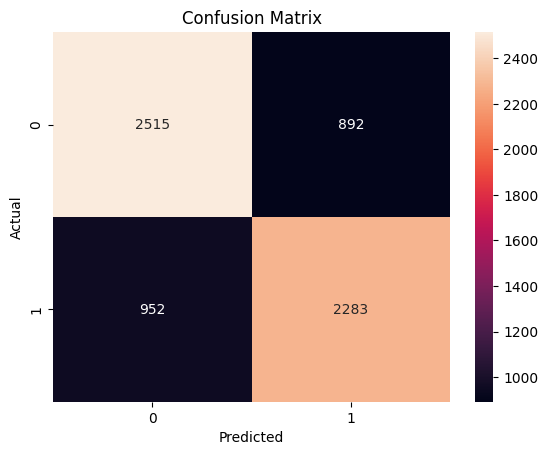

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_y, predictions)
sns.heatmap(cm, annot=True , fmt ='d')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

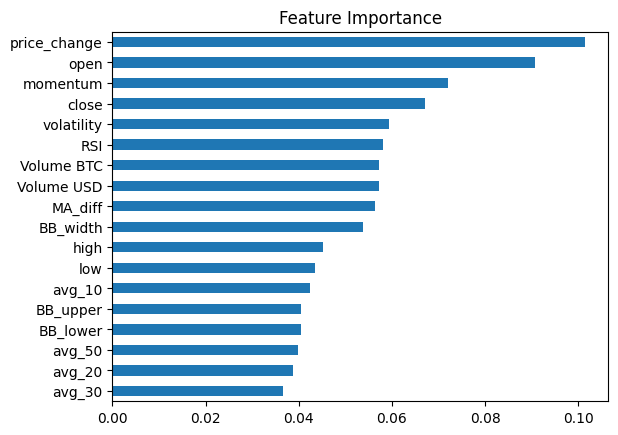

In [61]:
feat_imp = pd.Series(
    my_mod.feature_importances_,
    index = X.columns
)

feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [ ]:
import numpy as np
print("0 predictions:", np.sum(predictions==0))
print("1 predictions:", np.sum(predictions==1))

0 predictions: 12445
1 predictions: 5226


In [70]:
import yfinance as yf

btc = yf.download('BTC-USD', period='3d', interval='1h')
btc.reset_index(inplace=True)

/tmp/ipykernel_4683/4001650897.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', period='3d', interval='1h')
[*********************100%***********************]  1 of 1 completed


In [71]:
btc.columns = btc.columns.droplevel(1)
btc.columns = ['Datetime', 'Close', 'High', 'Low', 'Open', 'Volume']

btc['avg_10'] = btc['Close'].rolling(10).mean()
btc['avg_20'] = btc['Close'].rolling(20).mean()
btc['avg_30'] = btc['Close'].rolling(30).mean()
btc['avg_50'] = btc['Close'].rolling(50).mean()
btc['momentum'] = btc['Close'] - btc['Close'].shift(5)
btc['MA_diff'] = btc['avg_10'] - btc['avg_30']
btc['price_change'] = btc['Close'].pct_change()
btc['volatility'] = btc['Close'].rolling(10).std()

delta = btc['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
btc['RSI'] = 100 - (100 / (1 + gain/loss))

btc['BB_upper'] = btc['avg_20'] + 2 * btc['Close'].rolling(20).std()
btc['BB_lower'] = btc['avg_20'] - 2 * btc['Close'].rolling(20).std()
btc['BB_width'] = btc['BB_upper'] - btc['BB_lower']

btc.dropna(inplace=True)

In [75]:
X_new = btc[['Open', 'High', 'Low', 'Close', 'Volume',
             'avg_10', 'avg_20', 'avg_30', 'avg_50',
             'momentum', 'MA_diff', 'price_change',
             'volatility', 'RSI', 'BB_upper',
             'BB_lower', 'BB_width']]

X_new = X_new.copy()
X_new['Volume USD'] = X_new['Volume'] * X_new['Close']

X_new.columns = ['open', 'high', 'low', 'close', 'Volume BTC',
                 'avg_10', 'avg_20', 'avg_30', 'avg_50',
                 'momentum', 'MA_diff', 'price_change',
                 'volatility', 'RSI', 'BB_upper',
                 'BB_lower', 'BB_width', 'Volume USD']

X_new = X_new[['open', 'high', 'low', 'close', 'Volume BTC',
               'Volume USD', 'avg_50', 'momentum', 'avg_10',
               'avg_30', 'MA_diff', 'price_change', 'volatility',
               'avg_20', 'RSI', 'BB_upper', 'BB_lower', 'BB_width']]

prediction = xgb_mod.predict(X_new.tail(1))
print("Prediction:", "Price Badhega 📈" if prediction[0]==1 else "Price Girega")

Prediction: Price Girega


### Visualizing Predictions for Current Bitcoin Data

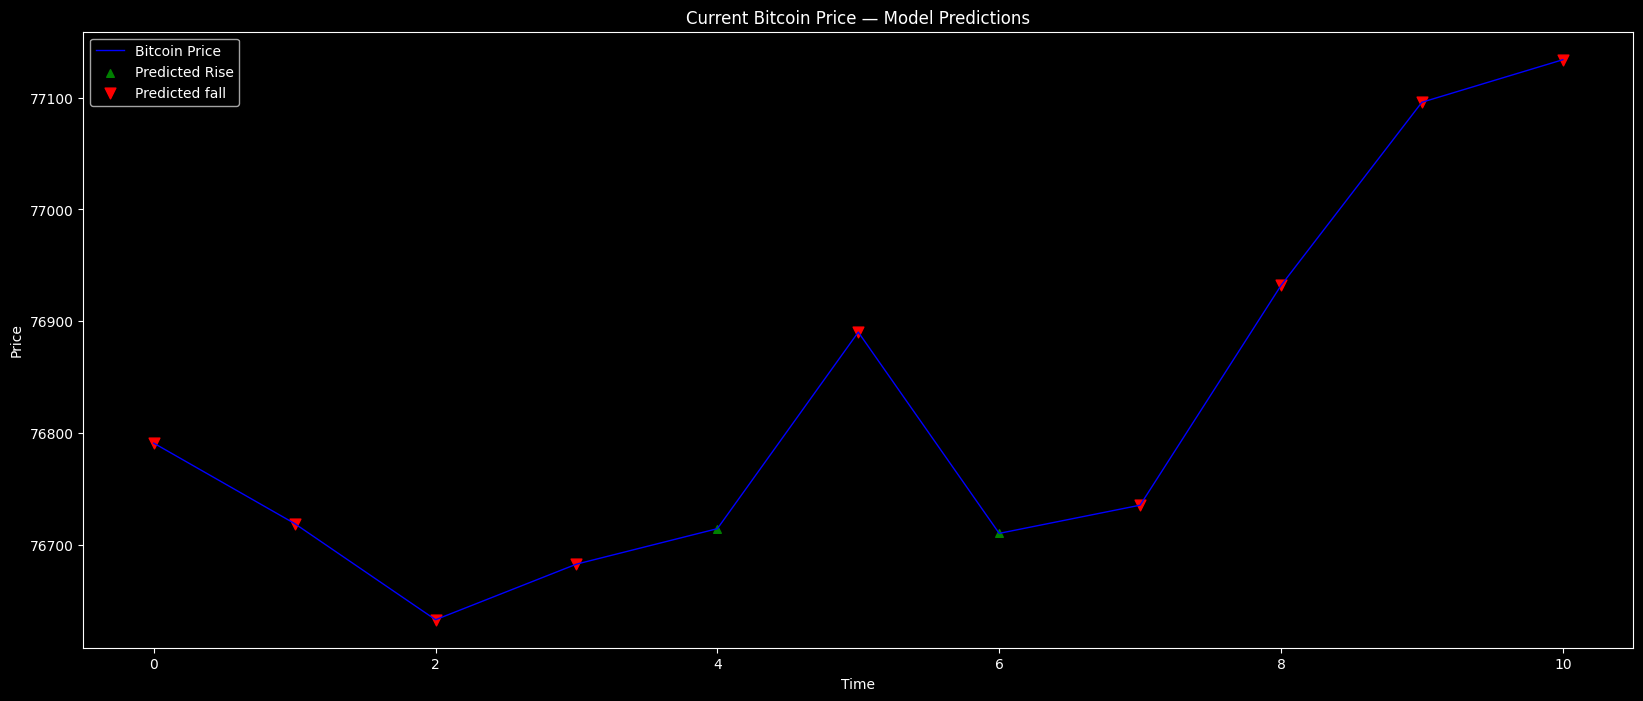

In [76]:
current_predictions = xgb_mod.predict(X_new)
actual_price_current = X_new['close']
predictions_series_current = pd.Series(current_predictions, index=actual_price_current.index)

plt.style.use('dark_background')
plt.figure(figsize=(20,8))

plt.plot(actual_price_current.values, color='blue',
         label='Bitcoin Price', linewidth=1)

plt.scatter(
    predictions_series_current[predictions_series_current==1].index - actual_price_current.index[0],
    actual_price_current[predictions_series_current==1].values,
    color='green', label='Predicted Rise',
    marker='^', s=30 )

plt.scatter(
    predictions_series_current[predictions_series_current==0].index - actual_price_current.index[0],
    actual_price_current[predictions_series_current==0].values,
    color='red', label='Predicted fall ',
    marker='v', s=60)

plt.title('Current Bitcoin Price — Model Predictions')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()
plt.show()